# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [108]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [109]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('../data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="../data/GSE139307.pkl")

# TODO: Inspect dataset shapes and missing values
# TODO: Print basic summary statistics for each dataset


Successfully loaded heart disease data with 1025 rows


/Users/jasmineliu/Documents/CSCI1851/homework-3-jasmineliu0114/src/hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


In [110]:
# Heart data
print(X_clf.shape)
print(y_clf.shape)

# Preprocess heart data
# Check for missing values
print(X_clf.isna().sum())

# Check for duplicate rows
print(X_clf.duplicated().sum())

(1025, 13)
(1025,)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
723


## Classification Task (Heart Disease)

Exploring classification dataset...


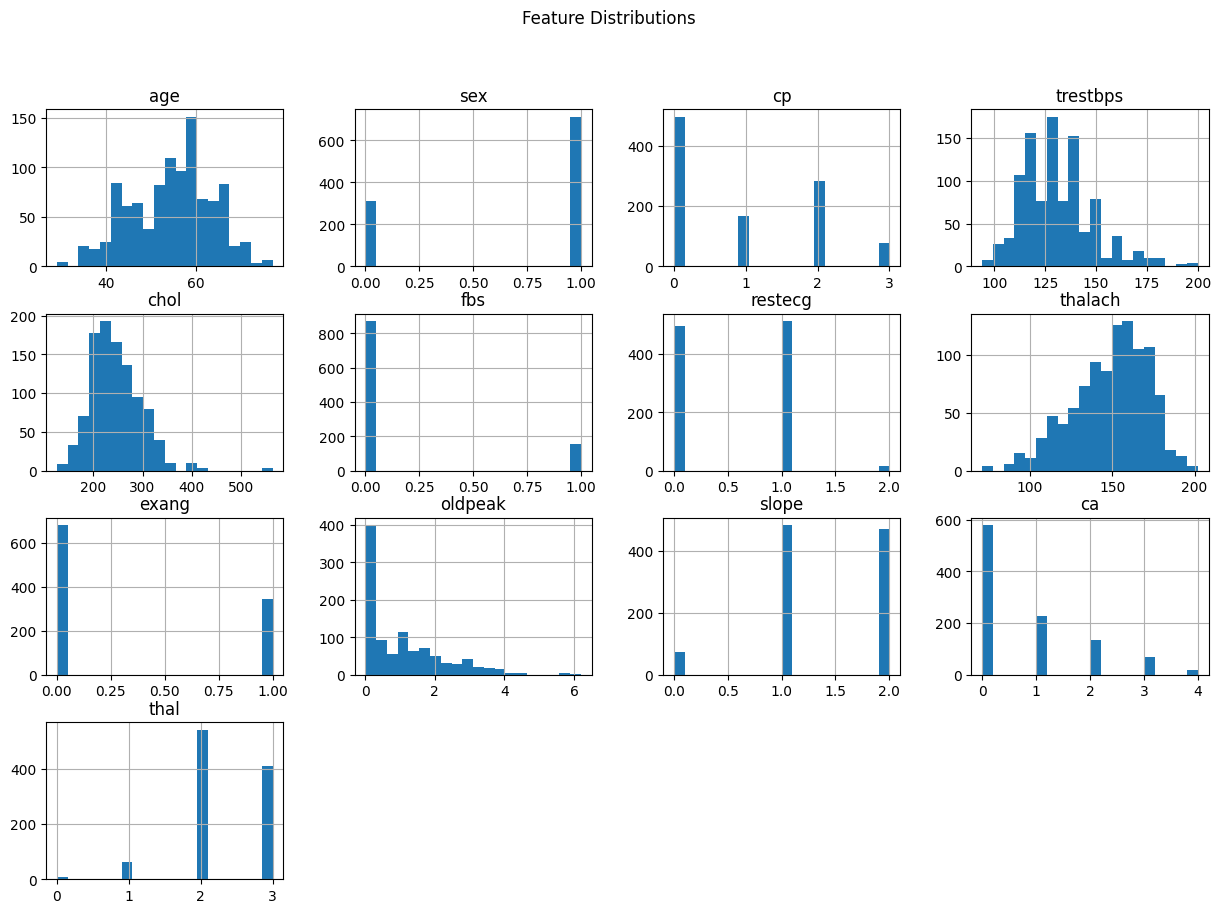

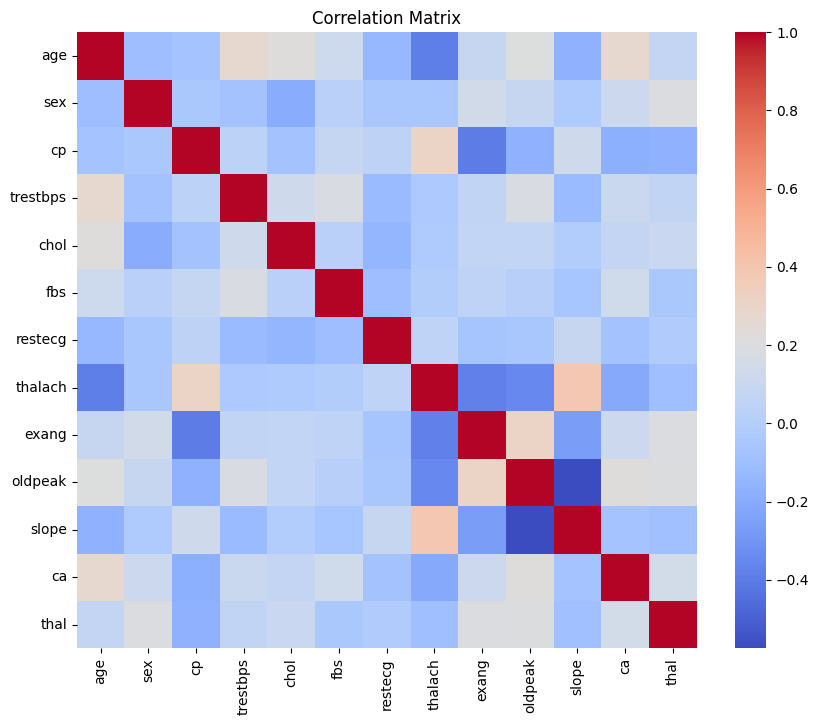

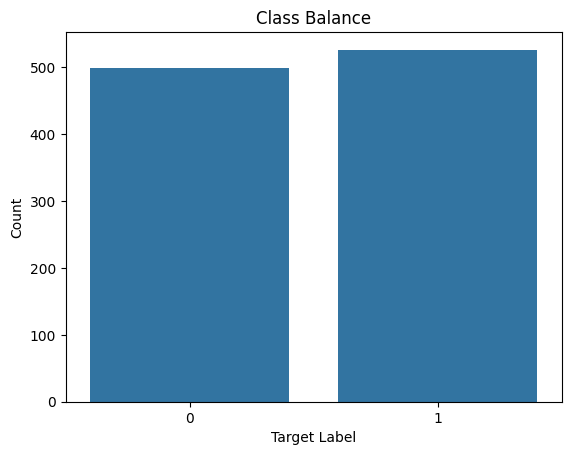

In [111]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils
explore_classification_data(X_clf, y_clf)

In [112]:
# TODO: Split X_clf and y_clf into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)


### Unique row-level split to avoid leakage

# Combine features and label
heart_combined = pd.concat([X_clf, y_clf], axis=1)
# Drop duplicated rows
df_heart_unique = heart_combined.drop_duplicates(keep='first')

train_unique, test_unique = train_test_split(
    df_heart_unique,
    test_size=0.2,
    random_state=42,
    stratify=df_heart_unique['target']
)

# merge back duplicates
train_df = heart_combined.merge(train_unique, how="inner")
test_df = heart_combined.merge(test_unique, how="inner")

X_train = train_df.drop("target", axis=1)
y_train = train_df["target"]

X_test = test_df.drop("target", axis=1)
y_test = test_df["target"]

### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [7]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_classifier(kernel=..., C=..., degree=..., gamma=...)),
# ])


In [113]:
def build_pipeline(task="classification", 
                   kernel="rbf", 
                   C=1.0, 
                   degree=3, 
                   gamma="scale", 
                   pca=False, 
                   n_components = 100):
    pipeline_steps = [("imputer", SimpleImputer(strategy="mean")),
                      ("scaler", StandardScaler())]
    if pca:
        pipeline_steps.append(("pca", PCA(n_components=n_components)))
    if task == "classification":
        pipeline_steps.append(("model", svm_classifier(kernel=kernel, C=C, degree=degree, gamma=gamma)))
    else:
        pipeline_steps.append(("model", svm_regressor(kernel=kernel, C=C, degree=degree, gamma=gamma)))
            
    return Pipeline(pipeline_steps)

### Kernel Experiments

In [9]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernel_values = ["linear", "poly", "rbf"]
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.01, 0.1, 1, 10]
degree_values = [2, 3, 4]

train_metrics_dict = {}
test_metrics_dict = {}
for kernel in kernel_values:
    train_kernel_dict = {}
    test_kernel_dict = {}
    for c in C_values:
        train_c_dict = {}
        test_c_dict = {}
        for gamma in gamma_values:
            train_gamma_dict = {}
            test_gamma_dict = {}
            for degree in degree_values:
                pipeline = build_pipeline(task="classification", kernel=kernel, C=c, degree=degree, gamma=gamma)
                pipeline.fit(X_train, y_train)
                train_metrics = evaluate_classifier(pipeline, X_test=X_train, y_test=y_train)
                test_metrics = evaluate_classifier(pipeline, X_test=X_test, y_test=y_test)
                train_gamma_dict[degree] = train_metrics
                test_gamma_dict[degree] = test_metrics
            train_c_dict[gamma] = train_gamma_dict
            test_c_dict[gamma] = test_gamma_dict
        train_kernel_dict[c] = train_c_dict
        test_kernel_dict[c] = test_c_dict
    train_metrics_dict[kernel] = train_kernel_dict
    test_metrics_dict[kernel] = test_kernel_dict

In [ ]:
# Best linear kernel hyperparameters
k_dict_test = test_metrics_dict['linear']
k_dict_train = train_metrics_dict['linear']
best_C = None
best_gamma = None
best_degree = None
best_accuracy = 0

for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            acc = k_dict_test[c][gamma][degree]['accuracy']
            if acc > best_accuracy:
                best_C = c
                best_gamma = gamma
                best_degree = degree
                best_accuracy = acc
            # print(f"C: {c}, gamma: {gamma}, degree: {degree}: {acc}")
print(f"[Train]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_train[best_C][best_gamma][best_degree]}")
print(f"[Test]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_test[best_C][best_gamma][best_degree]}")

[Train]C: 0.01, gamma: 0.01, degree: 2: {'accuracy': 0.8473748473748474, 'precision': 0.8040816326530612, 'recall': 0.9314420803782506, 'f1': 0.8630887185104053}
[Test]C: 0.01, gamma: 0.01, degree: 2: {'accuracy': 0.7912621359223301, 'precision': 0.7459016393442623, 'recall': 0.883495145631068, 'f1': 0.8088888888888889}


In [ ]:
# Best polynomial kernel hyperparameters
k_dict_test = test_metrics_dict['poly']
k_dict_train = train_metrics_dict['poly']
best_C = None
best_gamma = None
best_degree = None
best_accuracy = 0

for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            acc = k_dict_test[c][gamma][degree]['accuracy']
            if acc > best_accuracy:
                best_C = c
                best_gamma = gamma
                best_degree = degree
                best_accuracy = acc
            # print(f"C: {c}, gamma: {gamma}, degree: {degree}: {acc}")
print(f"[Train]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_train[best_C][best_gamma][best_degree]}")
print(f"[Test]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_test[best_C][best_gamma][best_degree]}")

[Train]C: 1, gamma: 0.1, degree: 3: {'accuracy': 0.9768009768009768, 'precision': 0.9570135746606335, 'recall': 1.0, 'f1': 0.9780346820809248}
[Test]C: 1, gamma: 0.1, degree: 3: {'accuracy': 0.8252427184466019, 'precision': 0.8252427184466019, 'recall': 0.8252427184466019, 'f1': 0.8252427184466019}


In [ ]:
# Best RBF kernel hyperparameters
k_dict_test = test_metrics_dict['rbf']
k_dict_train = train_metrics_dict['rbf']
best_C = None
best_gamma = None
best_degree = None
best_accuracy = 0

for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            acc = k_dict_test[c][gamma][degree]['accuracy']
            if acc > best_accuracy:
                best_C = c
                best_gamma = gamma
                best_degree = degree
                best_accuracy = acc
            # print(f"C: {c}, gamma: {gamma}, degree: {degree}: {acc}")
print(f"[Train]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_train[best_C][best_gamma][best_degree]}")
print(f"[Test]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_test[best_C][best_gamma][best_degree]}")

[Train]C: 0.1, gamma: 0.01, degree: 2: {'accuracy': 0.8351648351648352, 'precision': 0.7868525896414342, 'recall': 0.933806146572104, 'f1': 0.8540540540540541}
[Test]C: 0.1, gamma: 0.01, degree: 2: {'accuracy': 0.8106796116504854, 'precision': 0.7711864406779662, 'recall': 0.883495145631068, 'f1': 0.8235294117647058}


### Classification Metrics and Visuals

{'accuracy': 0.8252427184466019, 'precision': 0.8252427184466019, 'recall': 0.8252427184466019, 'f1': 0.8252427184466019}
auc: 0.8686021302667546


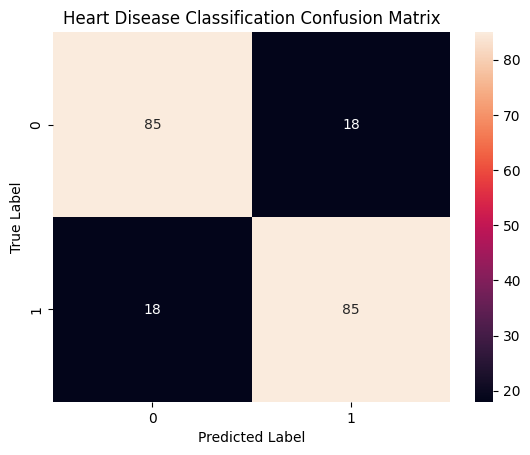

In [ ]:
# TODO: Compute accuracy and F1
# TODO: Compute ROC-AUC or PR-AUC
# TODO: Plot confusion matrix and ROC/PR curve

# Train model on best hyperparameters
heart_pipeline = build_pipeline(task="classification", kernel="poly", C=1, gamma=0.1, degree=3)
heart_pipeline.fit(X_train, y_train)
heart_metrics = evaluate_classifier(heart_pipeline, X_test, y_test)
y_proba = heart_pipeline.predict_proba(X_test)
rocauc = roc_auc_score(y_test, y_proba[:, 1])

print(heart_metrics)
print(f'auc: {rocauc}')

# Confusion matrix
y_heart_pred = heart_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_heart_pred)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Heart Disease Classification Confusion Matrix")
plt.show()

In [ ]:
# Train ROC-AUC score
y_proba_train = heart_pipeline.predict_proba(X_train)
rocauc = roc_auc_score(y_train, y_proba_train[:, 1])
rocauc

0.9990627313322349

### Hyperparameter Sensitivity

In [14]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel

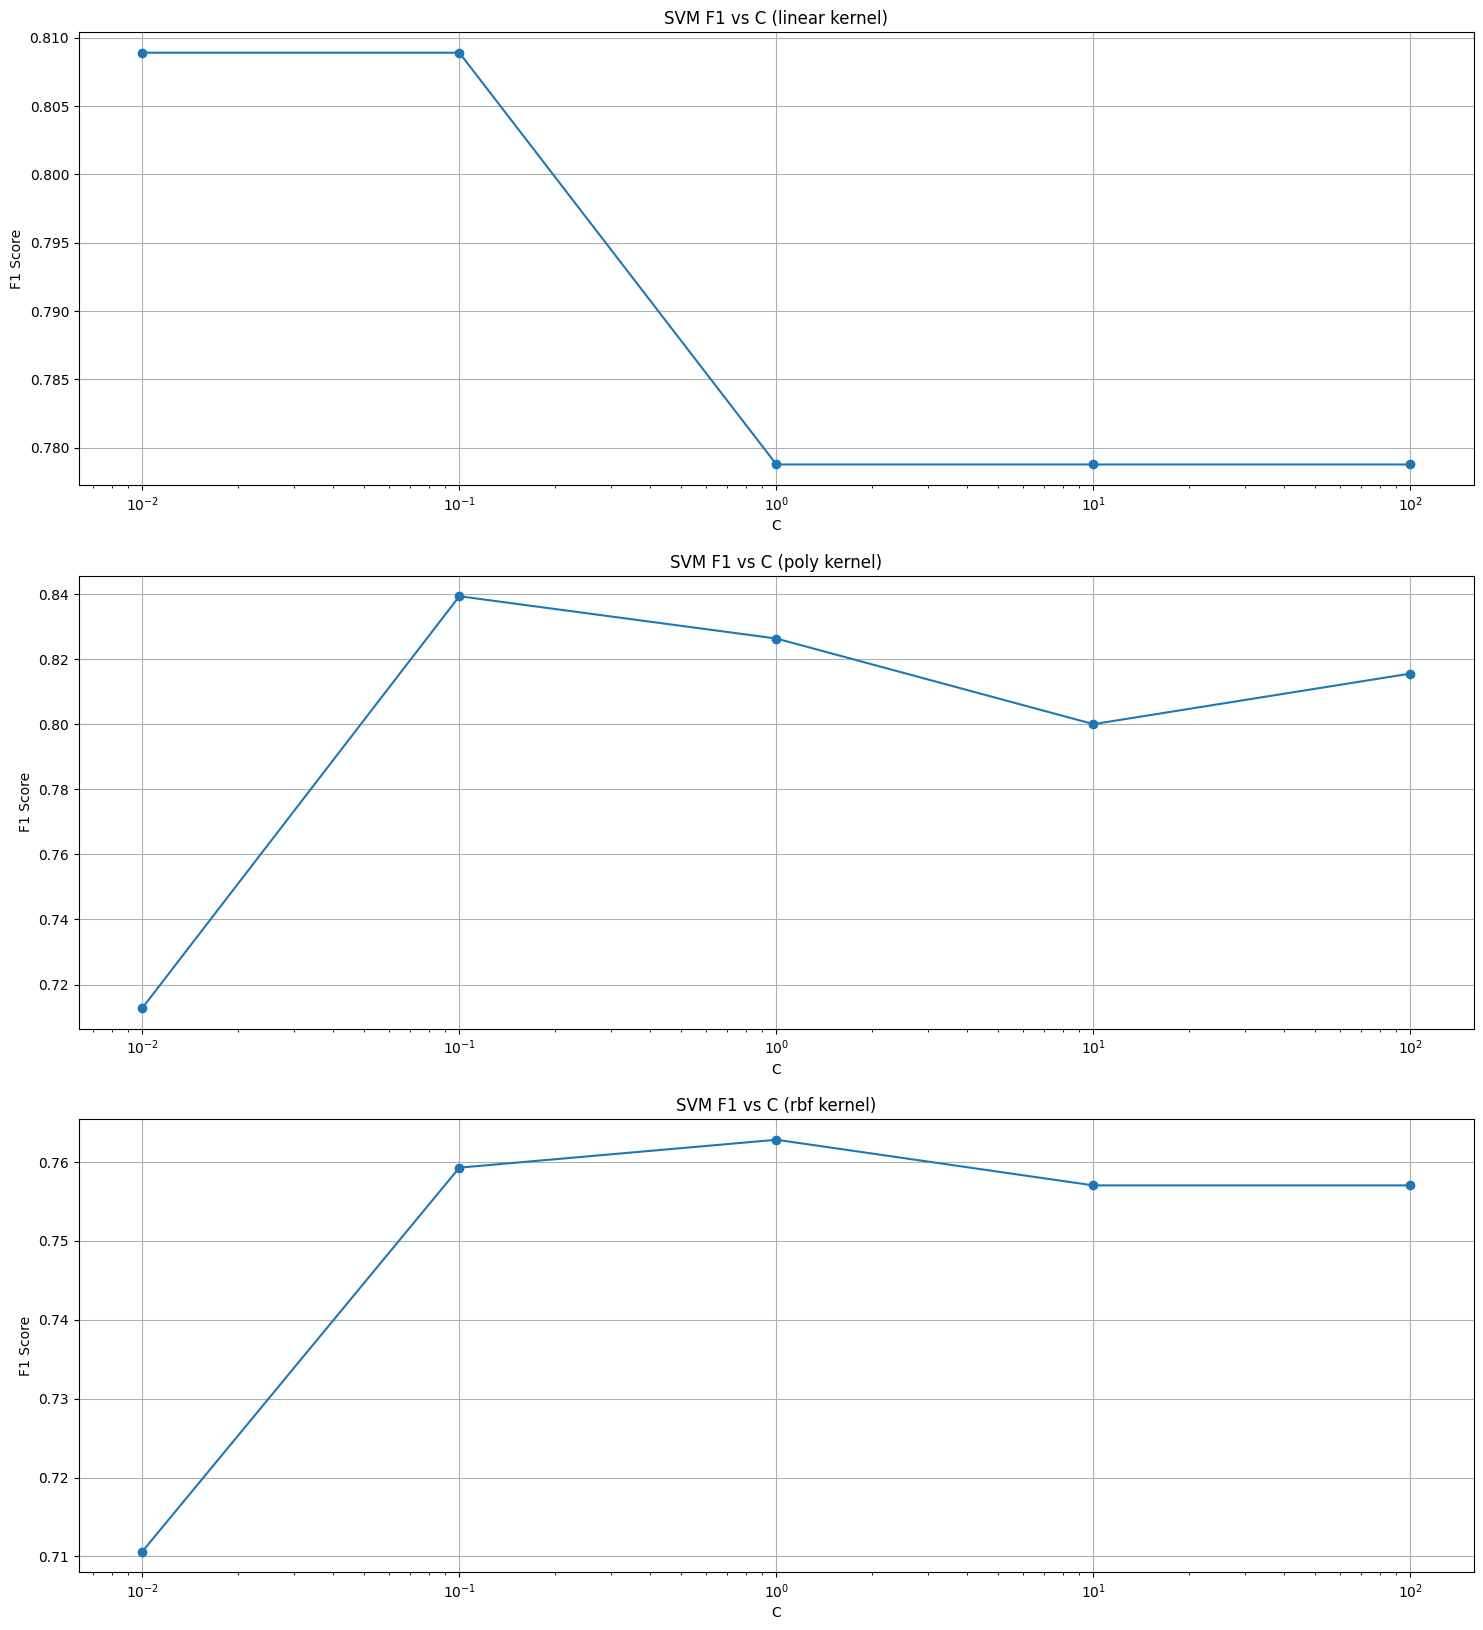

In [ ]:
# F1 scores vs C
f1_scores_C_dict = {}
fig, axes = plt.subplots(3, 1,figsize=(18, 20))
for i, kernel in enumerate(kernel_values):
    f1_scores = []
    for C in C_values:
        pipe = build_pipeline(task="classification", kernel=kernel, C=C, gamma="scale")
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        f1_scores.append(f1)
        
    f1_scores_C_dict[kernel] = f1_scores
    # plot
    ax = axes[i]
    ax.plot(C_values, f1_scores, marker='o')
    ax.set_xscale('log')
    ax.set_xlabel("C")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"SVM F1 vs C ({kernel} kernel)")
    ax.grid(True)
plt.show()

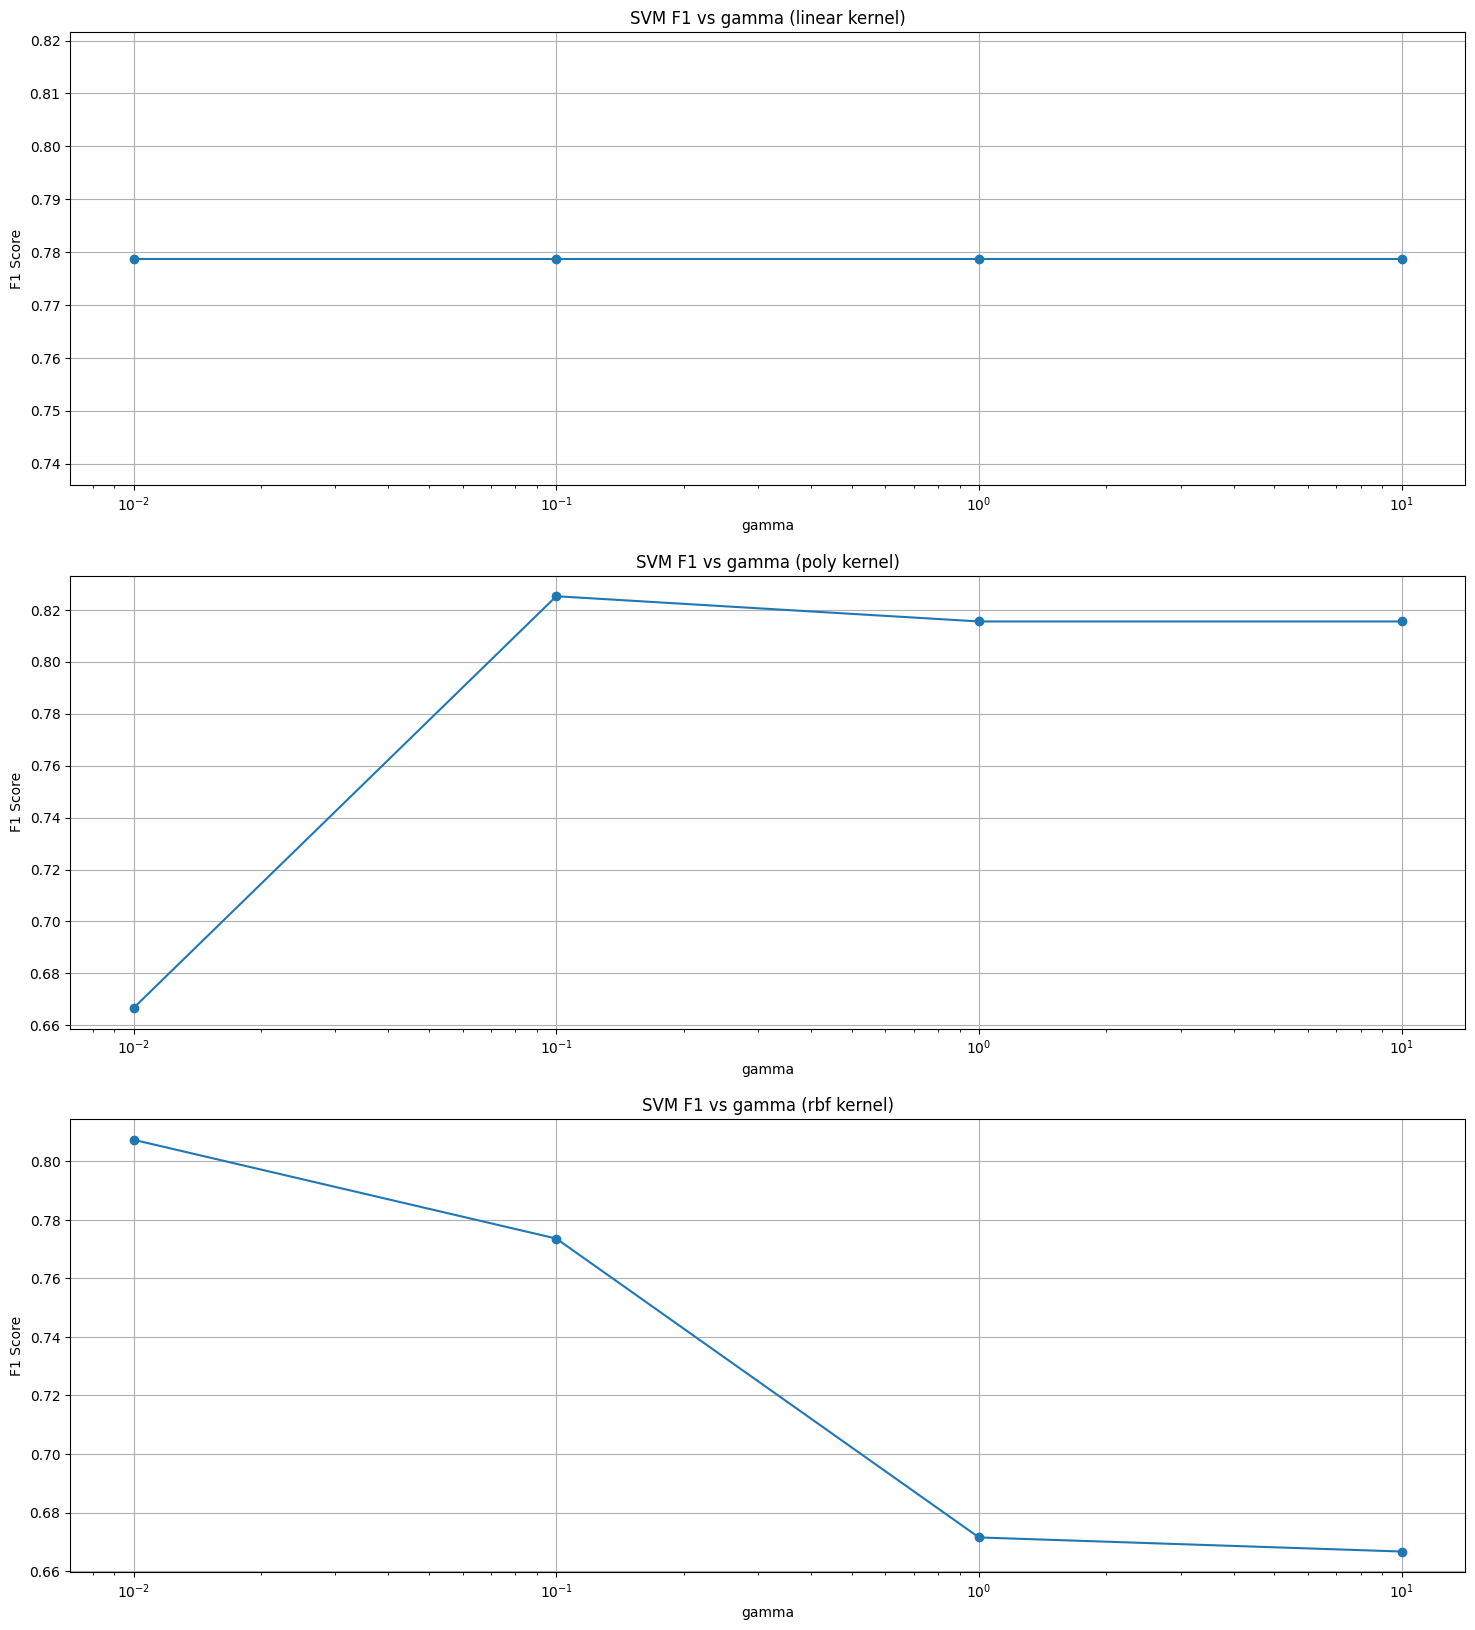

In [ ]:
# F1 scores vs gamma
f1_scores_gamma_dict = {}
fig, axes = plt.subplots(3, 1,figsize=(18, 20))
for i, kernel in enumerate(kernel_values):
    f1_scores = []
    for gamma in gamma_values:
        pipe = build_pipeline(task="classification", kernel=kernel, gamma=gamma)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        f1_scores.append(f1)
        
    f1_scores_gamma_dict[kernel] = f1_scores
    # plot
    ax = axes[i]
    ax.plot(gamma_values, f1_scores, marker='o')
    ax.set_xscale('log')
    ax.set_xlabel("gamma")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"SVM F1 vs gamma ({kernel} kernel)")
    ax.grid(True)
plt.show()

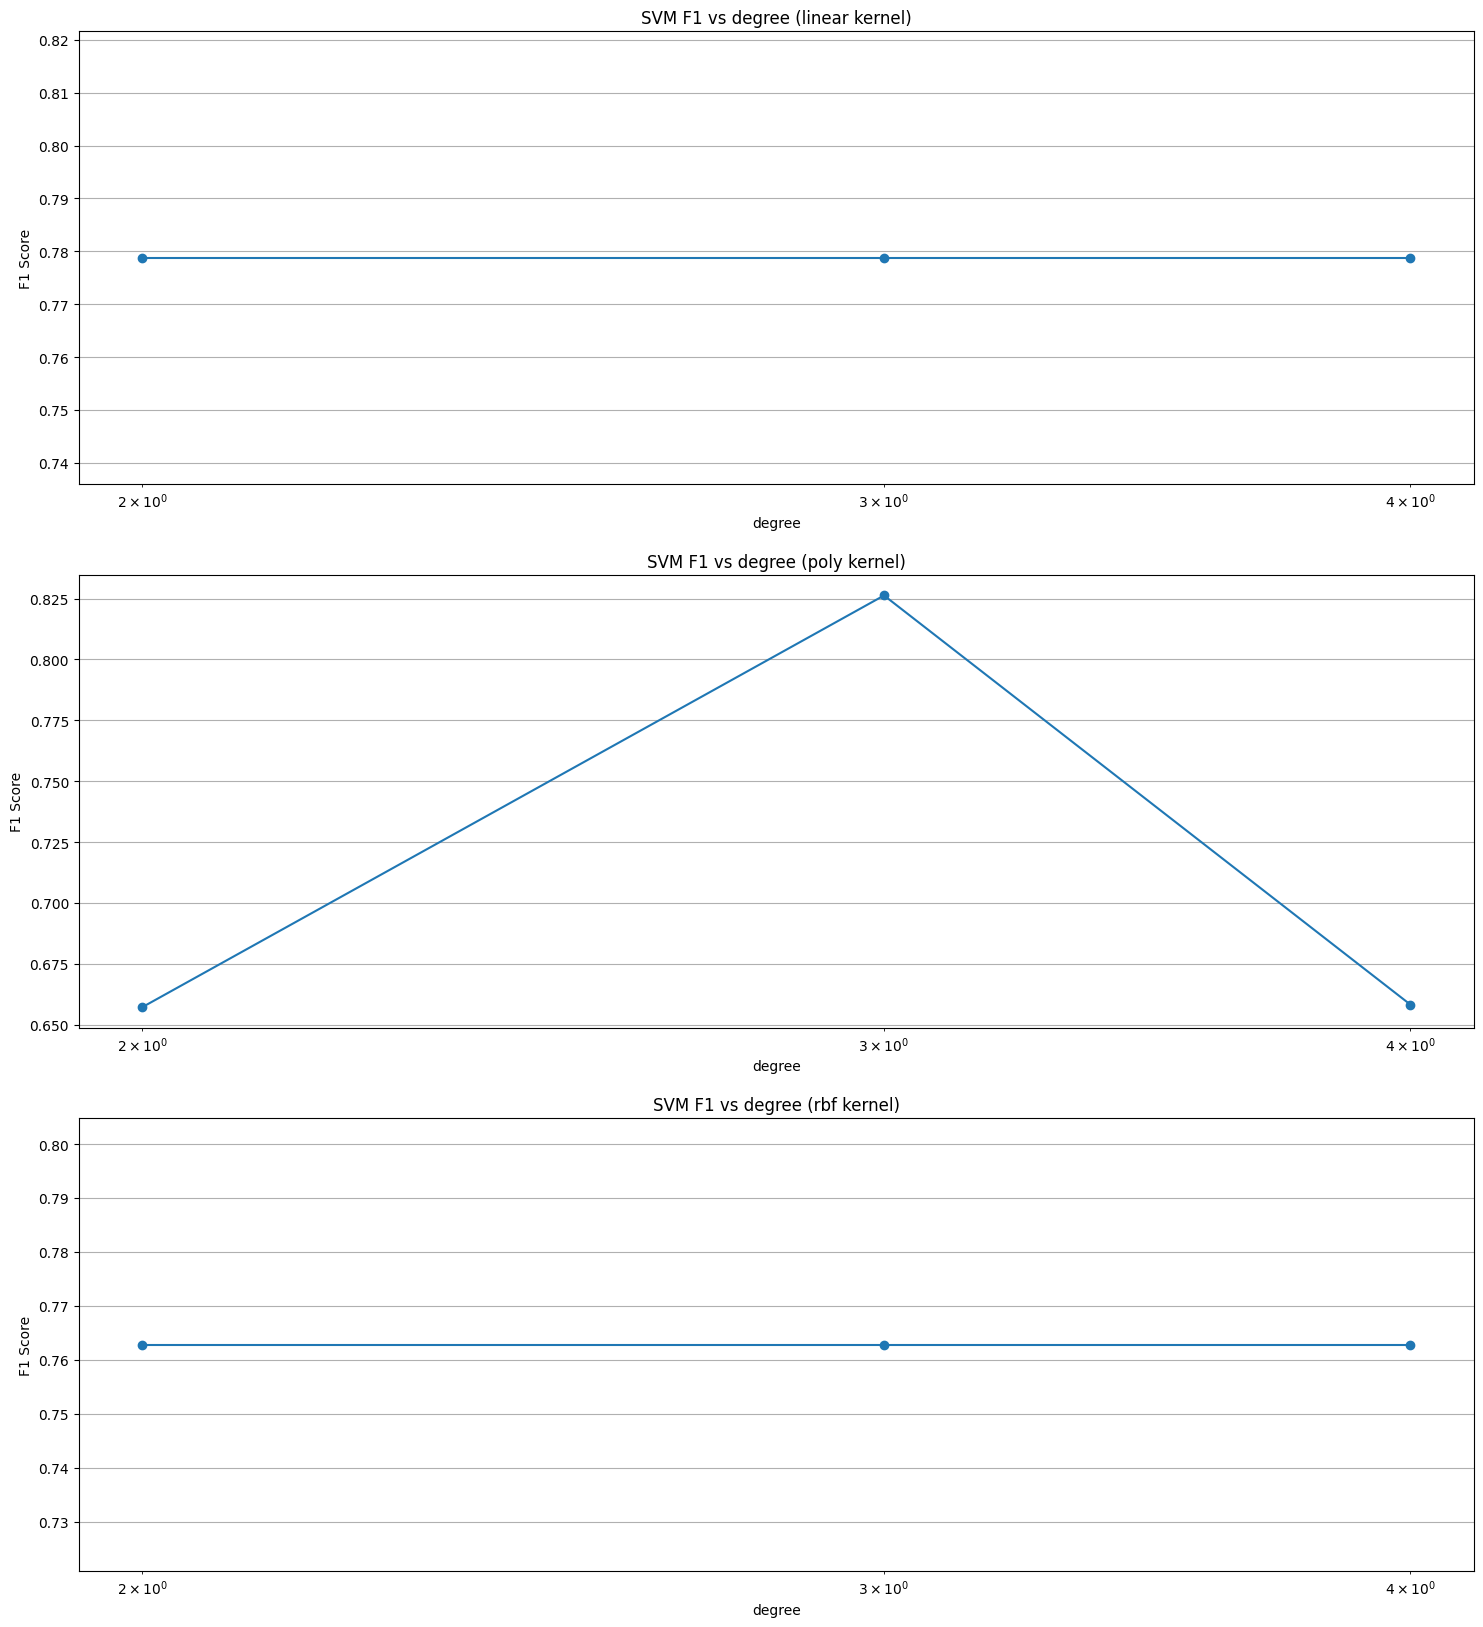

In [ ]:
# F1 scores vs degree
f1_scores_degree_dict = {}
fig, axes = plt.subplots(3, 1,figsize=(18, 20))
for i, kernel in enumerate(kernel_values):
    f1_scores = []
    for degree in degree_values:
        pipe = build_pipeline(task="classification", kernel=kernel, degree=degree, gamma="scale")
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        f1_scores.append(f1)
        
    f1_scores_degree_dict[kernel] = f1_scores
    # plot
    ax = axes[i]
    ax.plot(degree_values, f1_scores, marker='o')
    ax.set_xscale('log')
    ax.set_xlabel("degree")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"SVM F1 vs degree ({kernel} kernel)")
    ax.grid(True)
plt.show()

In [ ]:
# Plot decision boundary
plot_classification_results(X_test, y_test, heart_pipeline, 
                            "heart_decision_boundary.png", 
                            "Heart Disease Classification SVM Decision Boundary")

/Users/jasmineliu/Documents/CSCI1851/homework-3-jasmineliu0114/.hw3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


## Regression Task (Biological Aging)

In [116]:
df_aging.head(5)

,dataset,tissue_type,age,gender,cg00000029,cg00000108,cg00000109,cg00000165,cg00000236,cg00000289,...,ch.X.93511680F,ch.X.938089F,ch.X.94051109R,ch.X.94260649R,ch.X.967194F,ch.X.97129969R,ch.X.97133160R,ch.X.97651759F,ch.X.97737721F,ch.X.98007042R
GSM4137709,GSE139307,sperm,84.0,M,0.084811,0.920696,0.856851,0.084567,0.838699,0.247273,...,0.061751,0.045942,0.037631,0.056455,0.249872,0.049022,0.085691,0.037435,0.077820,0.106234
GSM4137710,GSE139307,sperm,69.0,M,0.099626,0.919073,0.890024,0.115541,0.852584,0.198103,...,0.075077,0.041849,0.032573,0.089790,0.250245,0.079095,0.079756,0.046229,0.091256,0.120241
GSM4137711,GSE139307,sperm,69.0,M,0.117228,0.920276,0.894317,0.117127,0.839258,0.213410,...,0.068679,0.049515,0.058097,0.079919,0.299758,0.079305,0.089815,0.065364,0.086864,0.156005
GSM4137712,GSE139307,sperm,69.0,M,0.077096,0.910204,0.908400,0.073885,0.861615,0.163276,...,0.070091,0.033289,0.038836,0.108213,0.295428,0.050731,0.099943,0.047597,0.078480,0.107480
GSM4137713,GSE139307,sperm,67.0,M,0.063524,0.911608,0.884643,0.079877,0.864654,0.176169,...,0.082368,0.038411,0.048787,0.088631,0.316694,0.041873,0.079303,0.048823,0.089010,0.117903


In [20]:
# TODO: Separate target column "target" from features
# X_reg = df_aging.drop(columns=["target"])
# y_reg = df_aging["target"]

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
# imputer = SimpleImputer(strategy="mean")
# X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

# TODO: Split X_reg and y_reg into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)


In [92]:
# cols with all nans
all_nan_cols = df_aging.columns[df_aging.isna().all()]
print(len(all_nan_cols))
print(all_nan_cols)

1
Index(['cg01550828'], dtype='object')


In [ ]:
# Separate target and features
selected_columns = [column for column in df_aging.columns if column.startswith('cg')]
X_reg = df_aging[selected_columns].drop(columns=['cg01550828'])
y_reg = df_aging["age"]

In [118]:
# Separate target and features
X_reg = df_aging.drop(columns=["dataset", "tissue_type", "age", "gender", 'cg01550828'])
y_reg = df_aging["age"]

In [119]:
# Check for missing values
rows_with_nan = X_reg[X_reg.isna().any(axis=1)]
len(rows_with_nan)
# imputation
imputer = SimpleImputer(strategy="mean")
X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

In [24]:
# Check for duplicate rows
print(X_reg.duplicated().sum())

0


In [120]:
print(X_reg.shape)
print(y_reg.shape)

(37, 485511)
(37,)


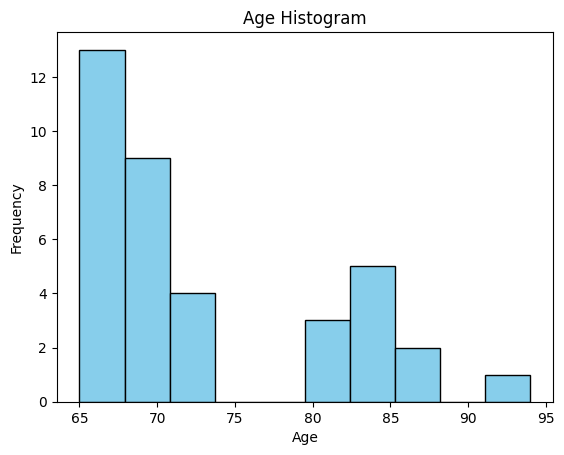

In [98]:
# Age label histogram
plt.hist(y_reg, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Histogram')
plt.show()

### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [26]:
# TODO: Build a leakage-free pipeline for regression
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_regressor(kernel=..., C=..., degree=..., gamma=...)),
# ])


### Kernel Experiments

In [27]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model


In [121]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [ ]:
# Hyperparameter tuning with PCA
kernel_values = ["linear", "poly", "rbf"]
C_values = [0.01, 0.1, 1, 10]
gamma_values = [0.01, 0.1, 1, 10]
degree_values = [2, 3, 4]

train_metrics_dict = {}
test_metrics_dict = {}
for kernel in kernel_values:
    train_kernel_dict = {}
    test_kernel_dict = {}
    for c in C_values:
        train_c_dict = {}
        test_c_dict = {}
        for gamma in gamma_values:
            train_gamma_dict = {}
            test_gamma_dict = {}
            for degree in degree_values:
                pipeline = build_pipeline(task="regression", kernel=kernel, C=c, degree=degree, gamma=gamma, pca=True, n_components=X_train.shape[0])
                pipeline.fit(X_train, y_train)
                train_metrics = evaluate_regressor(pipeline, X_test=X_train, y_test=y_train)
                test_metrics = evaluate_regressor(pipeline, X_test=X_test, y_test=y_test)
                train_gamma_dict[degree] = train_metrics
                test_gamma_dict[degree] = test_metrics
            train_c_dict[gamma] = train_gamma_dict
            test_c_dict[gamma] = test_gamma_dict
        train_kernel_dict[c] = train_c_dict
        test_kernel_dict[c] = test_c_dict
    train_metrics_dict[kernel] = train_kernel_dict
    test_metrics_dict[kernel] = test_kernel_dict

In [ ]:
# Hyperparameter tuning without PCA
kernel_values = ["linear", "poly", "rbf"]
C_values = [0.01, 0.1, 1, 10]
gamma_values = [0.01, 0.1, 1, 10]
degree_values = [2, 3, 4]

train_metrics_dict2 = {}
test_metrics_dict2 = {}
for kernel in kernel_values:
    train_kernel_dict = {}
    test_kernel_dict = {}
    for c in C_values:
        train_c_dict = {}
        test_c_dict = {}
        for gamma in gamma_values:
            train_gamma_dict = {}
            test_gamma_dict = {}
            for degree in degree_values:
                pipeline = build_pipeline(task="regression", kernel=kernel, C=c, degree=degree, gamma=gamma)
                pipeline.fit(X_train, y_train)
                train_metrics = evaluate_regressor(pipeline, X_test=X_train, y_test=y_train)
                test_metrics = evaluate_regressor(pipeline, X_test=X_test, y_test=y_test)
                train_gamma_dict[degree] = train_metrics
                test_gamma_dict[degree] = test_metrics
            train_c_dict[gamma] = train_gamma_dict
            test_c_dict[gamma] = test_gamma_dict
        train_kernel_dict[c] = train_c_dict
        test_kernel_dict[c] = test_c_dict
    train_metrics_dict2[kernel] = train_kernel_dict
    test_metrics_dict2[kernel] = test_kernel_dict

In [ ]:
# Best linear kernel hyperparameters
k_dict_test = test_metrics_dict['linear']
k_dict_train = train_metrics_dict['linear']
best_C = None
best_gamma = None
best_degree = None
best_r2 = -np.inf
best_rmse = np.inf

for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            r2 = k_dict_test[c][gamma][degree]['r2']
            rmse = k_dict_test[c][gamma][degree]['rmse']
            # if r2 > best_r2:
            if rmse < best_rmse:
                best_C = c
                best_gamma = gamma
                best_degree = degree
                best_r2 = r2
                best_rmse = rmse
print(f"[Train]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_train[best_C][best_gamma][best_degree]}")
print(f"[Test]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_test[best_C][best_gamma][best_degree]}")

[Train]C: 0.01, gamma: 0.01, degree: 2: {'mae': 0.09996104775636491, 'rmse': np.float64(0.0999612994877541), 'r2': 0.9998471536589045}
[Test]C: 0.01, gamma: 0.01, degree: 2: {'mae': 5.824970987585038, 'rmse': np.float64(6.465790332466198), 'r2': -0.2869708782580347}


In [ ]:
# Best polynomial kernel hyperparameters
k_dict_test = test_metrics_dict['poly']
k_dict_train = train_metrics_dict['poly']
best_C = None
best_gamma = None
best_degree = None
best_r2 = -np.inf
best_rmse = np.inf

for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            r2 = k_dict_test[c][gamma][degree]['r2']
            rmse = k_dict_test[c][gamma][degree]['rmse']
            # if r2 > best_r2:
            if rmse < best_rmse:
                best_C = c
                best_gamma = gamma
                best_degree = degree
                best_r2 = r2
                best_rmse = rmse
print(f"[Train]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_train[best_C][best_gamma][best_degree]}")
print(f"[Test]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_test[best_C][best_gamma][best_degree]}")

[Train]C: 0.01, gamma: 10, degree: 4: {'mae': 0.0969578939655461, 'rmse': np.float64(0.09822283807010769), 'r2': 0.9998524238359858}
[Test]C: 0.01, gamma: 10, degree: 4: {'mae': 5.419182349105345, 'rmse': np.float64(6.1956493224417315), 'r2': -0.18167797677106856}


In [ ]:
# Best RBF kernel hyperparameters
k_dict_test = test_metrics_dict['rbf']
k_dict_train = train_metrics_dict['rbf']
best_C = None
best_gamma = None
best_degree = None
best_r2 = -np.inf
best_rmse = np.inf

for c in C_values:
    for gamma in gamma_values:
        for degree in degree_values:
            r2 = k_dict_test[c][gamma][degree]['r2']
            rmse = k_dict_test[c][gamma][degree]['rmse']
            # if r2 > best_r2:
            if rmse < best_rmse:
                best_C = c
                best_gamma = gamma
                best_degree = degree
                best_r2 = r2
                best_rmse = rmse
print(f"[Train]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_train[best_C][best_gamma][best_degree]}")
print(f"[Test]C: {best_C}, gamma: {best_gamma}, degree: {best_degree}: {k_dict_test[best_C][best_gamma][best_degree]}")

[Train]C: 1, gamma: 0.01, degree: 2: {'mae': 5.488793103448276, 'rmse': np.float64(8.442540320837411), 'r2': -0.09027874909057743}
[Test]C: 1, gamma: 0.01, degree: 2: {'mae': 4.237500000000004, 'rmse': np.float64(5.700383759011318), 'r2': -0.000307840307840479}


### Regression Metrics and Visuals

In [122]:
# TODO: Compute MAE, RMSE, and R^2
# TODO: Plot parity (predicted vs actual) and residuals
# plot_regression_results(...)
# plot_residuals(...)

age_pipeline = build_pipeline(task="regression", kernel="rbf", C=1, gamma=0.01, pca=True, n_components=X_train.shape[0])
age_pipeline.fit(X_train, y_train)
age_metrics = evaluate_regressor(age_pipeline, X_test, y_test)
y_pred = age_pipeline.predict(X_test)

In [123]:
print(age_metrics)

{'mae': 4.237500000000004, 'rmse': np.float64(5.700383759011318), 'r2': -0.000307840307840479}


In [ ]:
# Plot parity
plot_regression_results(y_test, y_pred, "../plots/age_regression_results.png", "Predicted vs Actual Age")

In [ ]:
# Plot residuals
plot_residuals(y_test, y_pred, "../plots/age_regression_residuals.png")

In [104]:
y_pred

array([69.725, 69.725, 69.725, 69.725, 69.725, 69.725, 69.725, 69.725])

### Hyperparameter Sensitivity (Regression)

In [ ]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel


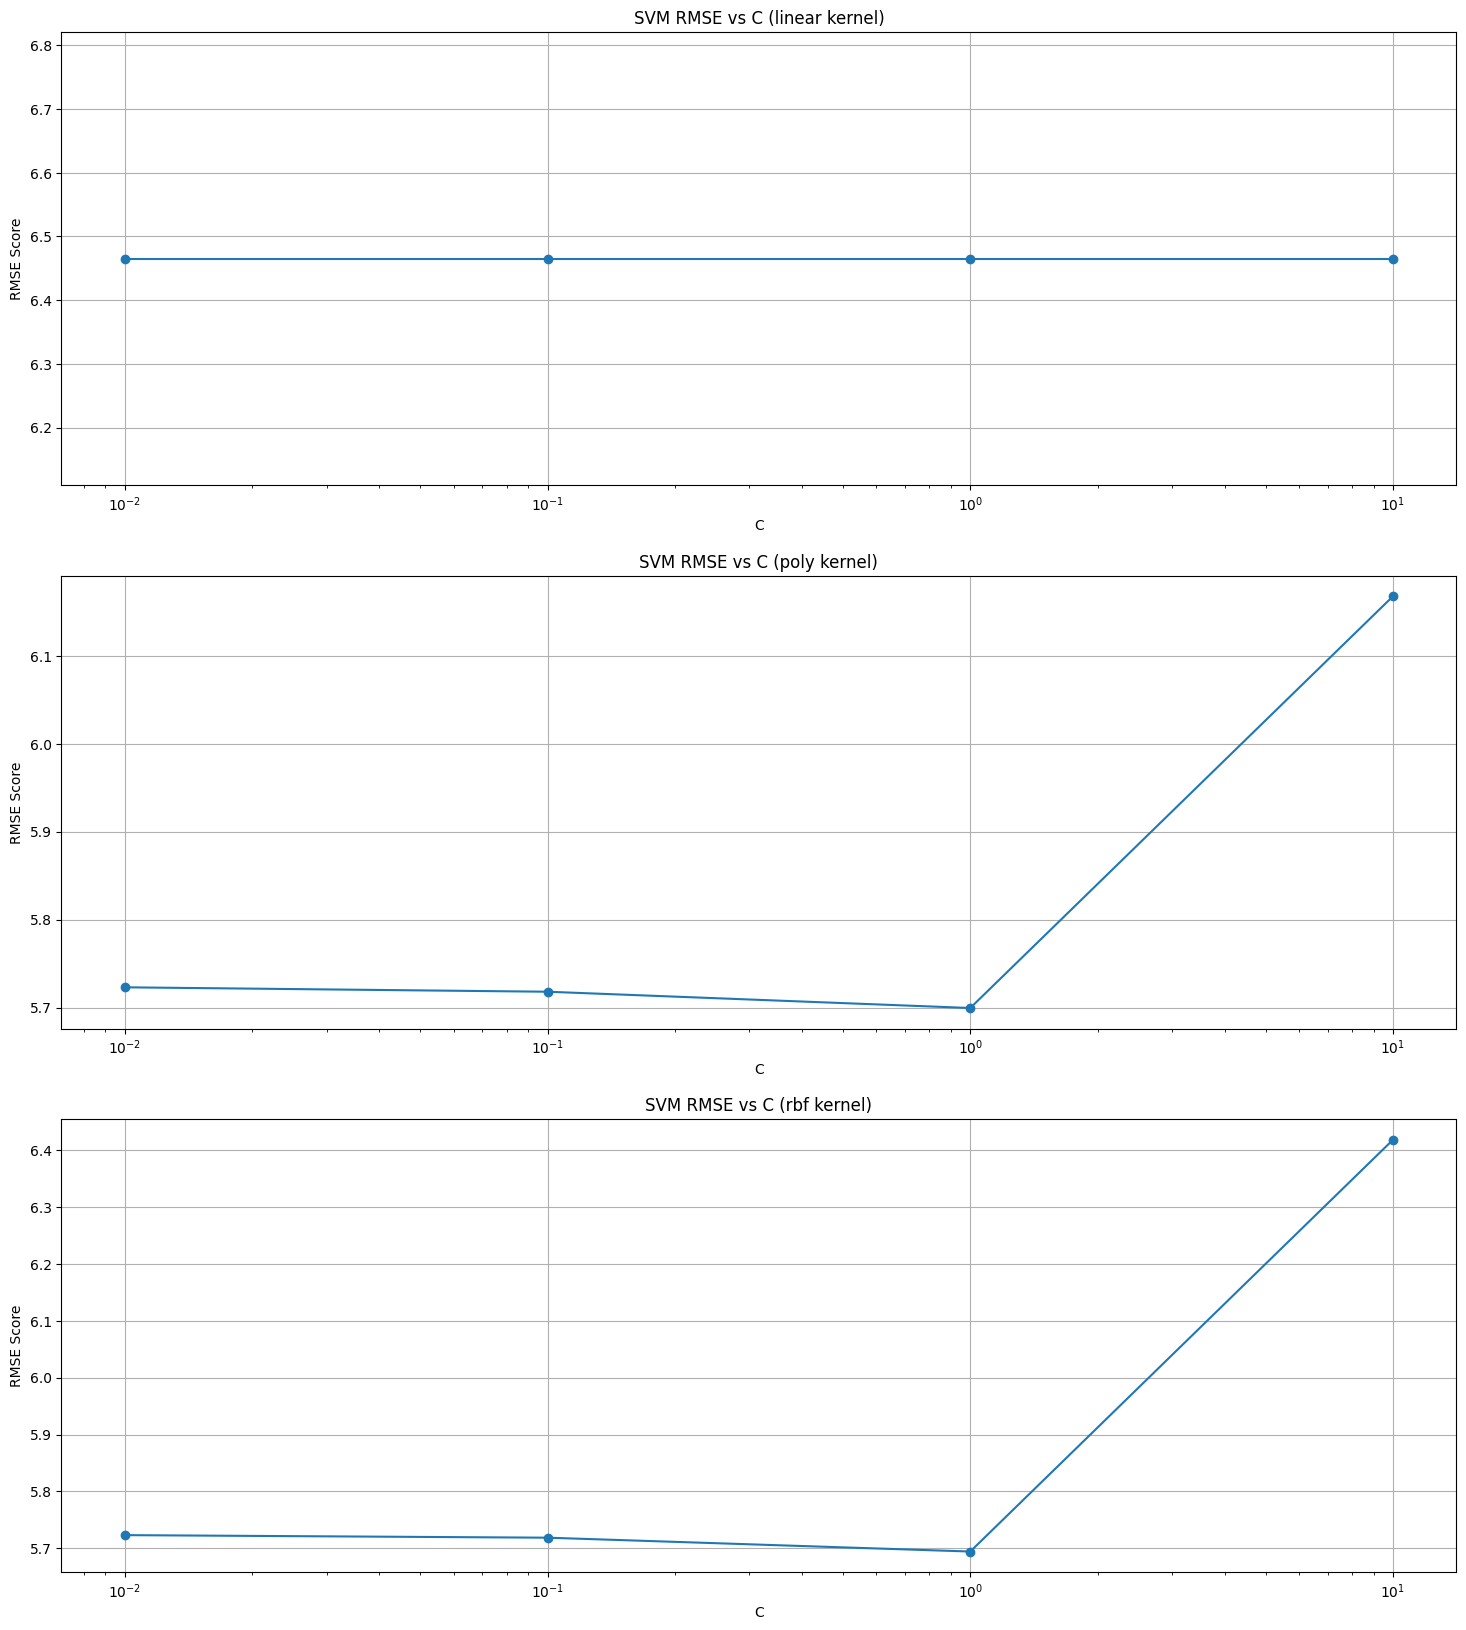

In [ ]:
# RMSE scores vs C
rmse_scores_C_dict = {}
fig, axes = plt.subplots(3, 1,figsize=(18, 20))
for i, kernel in enumerate(kernel_values):
    rmse_scores = []
    for C in C_values:
        pipe = build_pipeline(task="regression", kernel=kernel, C=C, gamma="scale")
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmse_scores.append(rmse)
        
    rmse_scores_C_dict[kernel] = rmse_scores
    # plot
    ax = axes[i]
    ax.plot(C_values, rmse_scores, marker='o')
    ax.set_xscale('log')
    ax.set_xlabel("C")
    ax.set_ylabel("RMSE Score")
    ax.set_title(f"SVM RMSE vs C ({kernel} kernel)")
    ax.grid(True)
plt.show()

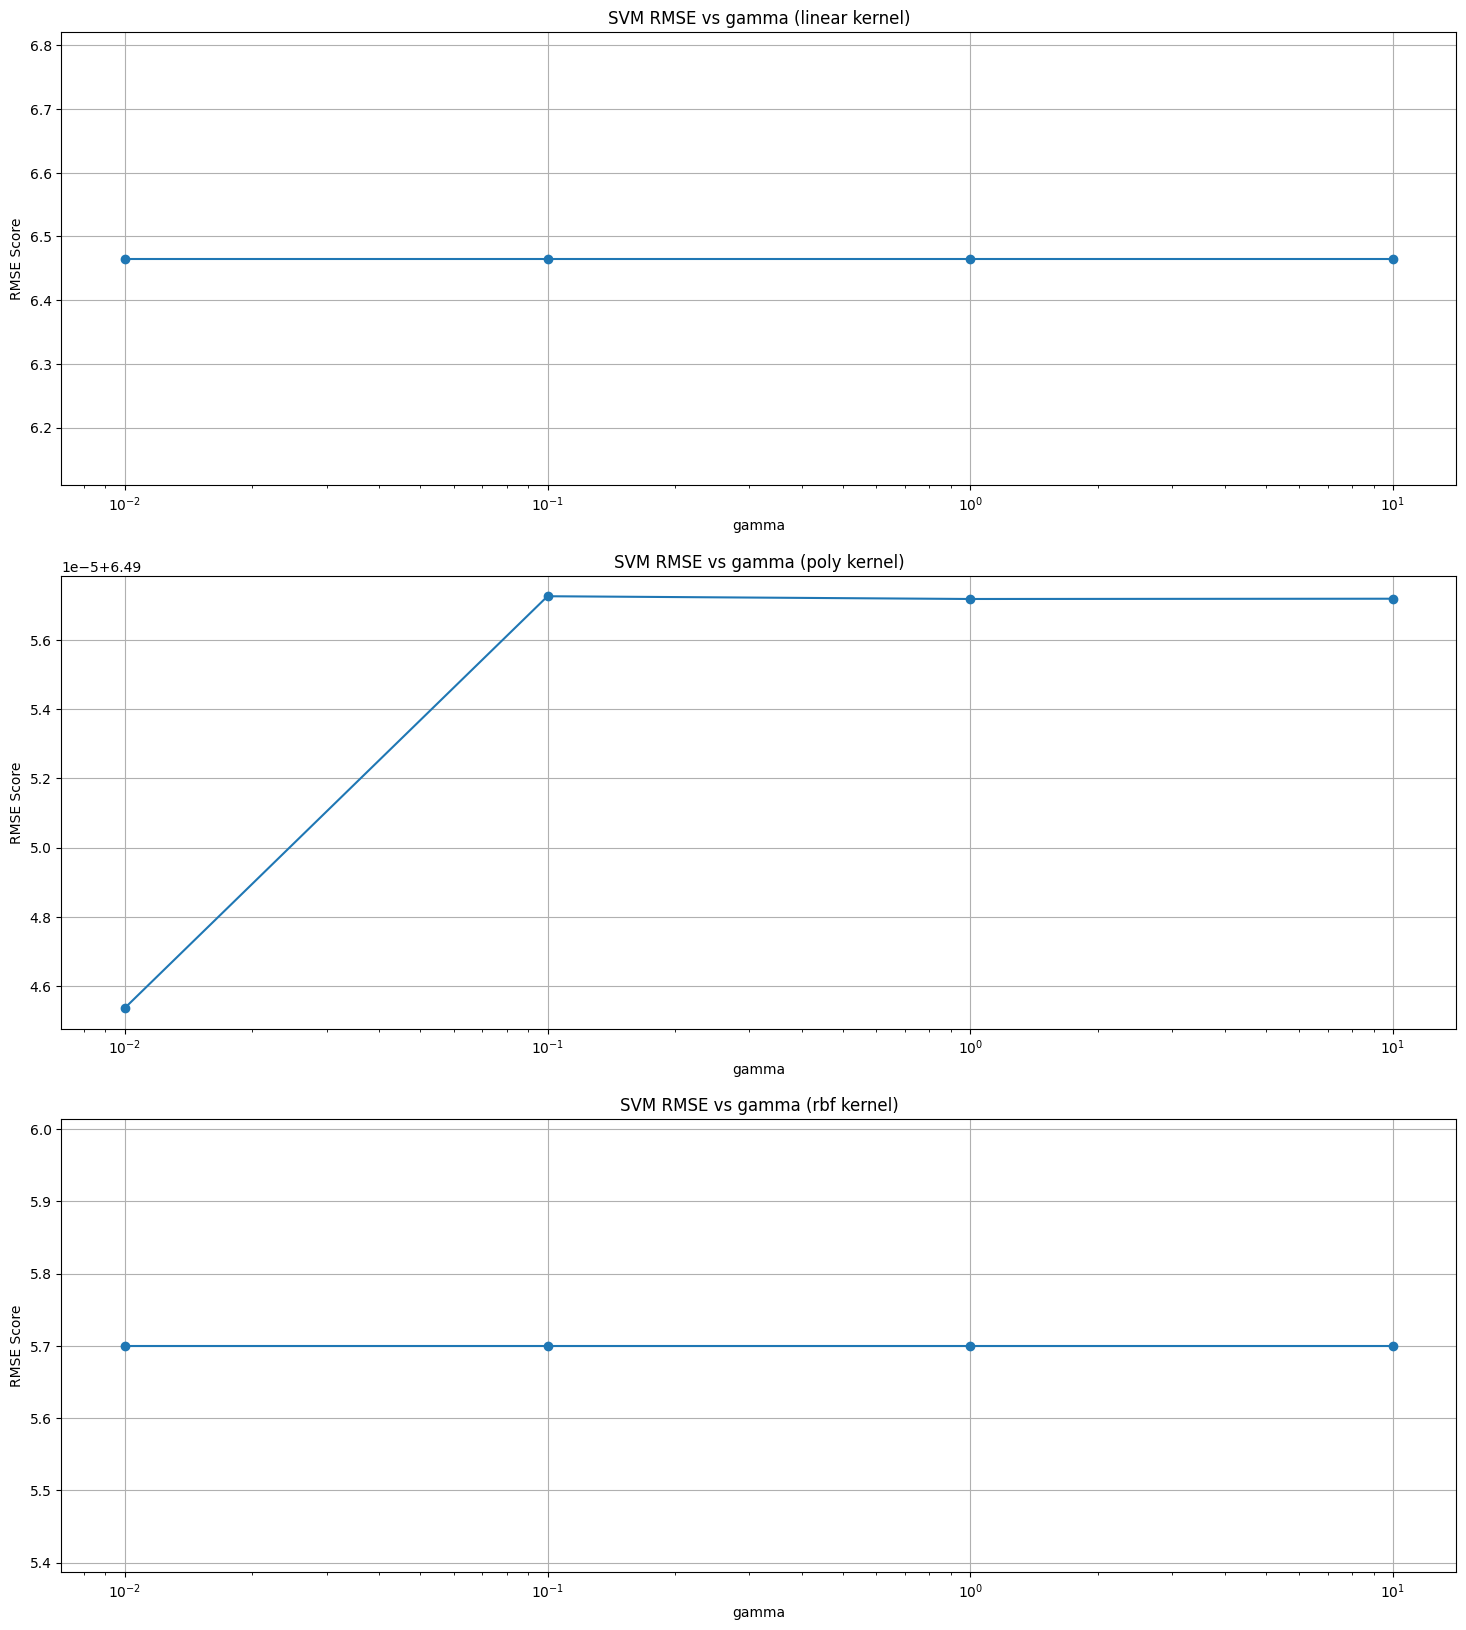

In [ ]:
# RMSE scores vs gamma
rmse_scores_gamma_dict = {}
fig, axes = plt.subplots(3, 1,figsize=(18, 20))
for i, kernel in enumerate(kernel_values):
    rmse_scores = []
    for gamma in gamma_values:
        pipe = build_pipeline(task="regression", kernel=kernel, gamma=gamma)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmse_scores.append(rmse)
        
    rmse_scores_gamma_dict[kernel] = rmse_scores
    # plot
    ax = axes[i]
    ax.plot(gamma_values, rmse_scores, marker='o')
    ax.set_xscale('log')
    ax.set_xlabel("gamma")
    ax.set_ylabel("RMSE Score")
    ax.set_title(f"SVM RMSE vs gamma ({kernel} kernel)")
    ax.grid(True)
plt.show()

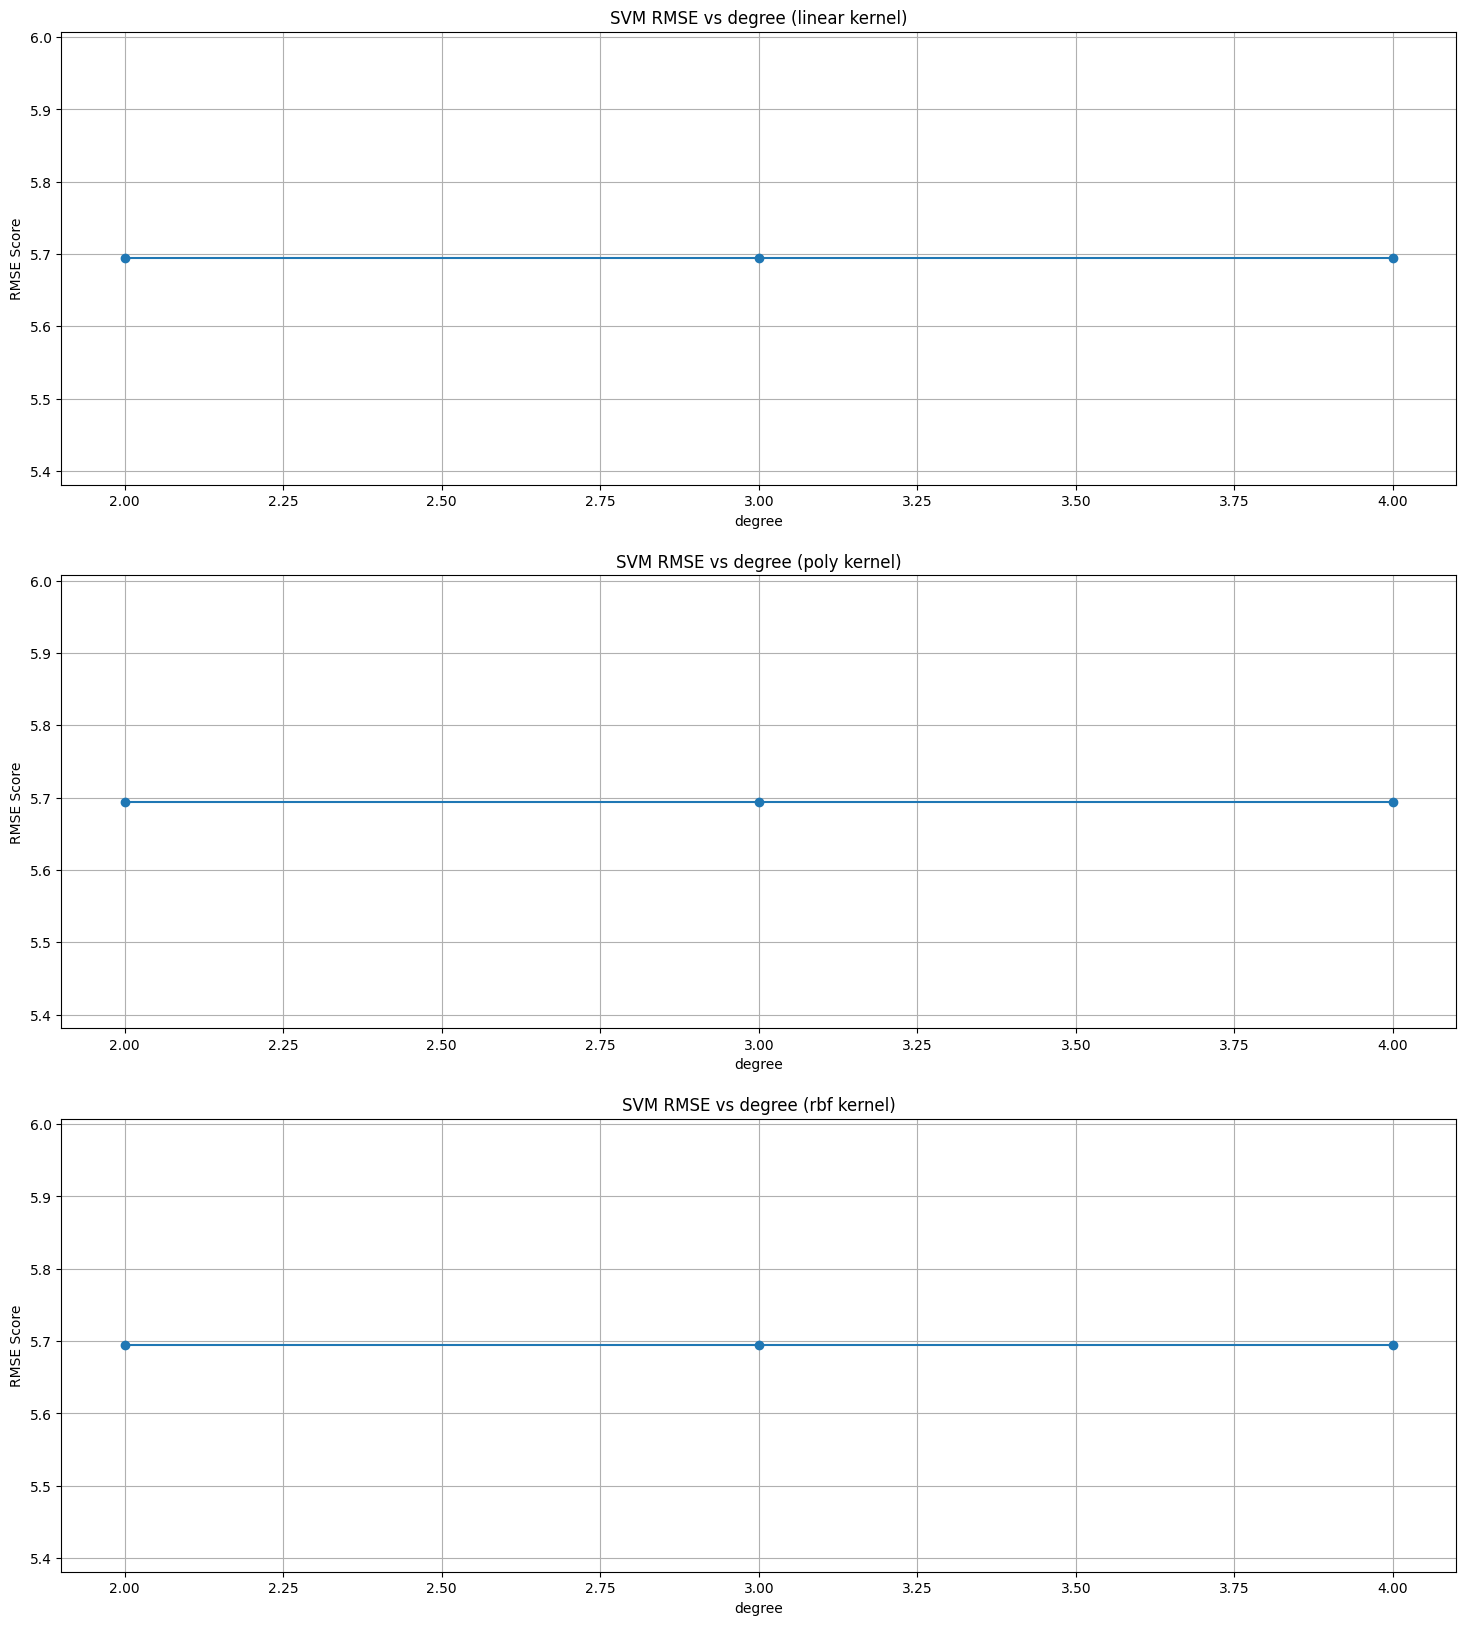

In [ ]:
# RMSE scores vs degree
rmse_scores_degree_dict = {}
fig, axes = plt.subplots(3, 1,figsize=(18, 20))
for i, kernel in enumerate(kernel_values):
    rmse_scores = []
    for degree in degree_values:
        pipe = build_pipeline(task="regression", degree=degree, gamma="scale")
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmse_scores.append(rmse)
        
    rmse_scores_degree_dict[kernel] = rmse_scores
    # plot
    ax = axes[i]
    ax.plot(degree_values, rmse_scores, marker='o')
    ax.set_xlabel("degree")
    ax.set_ylabel("RMSE Score")
    ax.set_title(f"SVM RMSE vs degree ({kernel} kernel)")
    ax.grid(True)
plt.show()